In [6]:
# Setup, ground truths
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SIGMA = 2

# x is a Numpy array of spatial coords
def exact_phi_1(x):
    # Calculates analytical solution for f(x) = x
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{x}{4} using derived bound. condition consts
    c1 = 1.0 / (8.0 *(1.0 - np.exp(2.0)))
    c2 = 1.0 / (8.0 * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + x / 4.0

    return phi




def exact_phi_2(x):
    # Calculates analytical solution for f(x) = sin(\pi x)
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{1}{\pi^2 + 4} sin(\pi x)

    c1 = -np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(2.0)))
    c2 = np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + (1.0 / (np.pi ** 2.0 + 4.0)) * np.sin(np.pi * x)

    return phi

In [2]:
#FFT Solver
# N is the number of grid points, exact_sol_func is exact soln, rhs_func is the rhs i.e. f(x) = x
def solve_bvp_fft(N, exact_sol_func, rhs_func):
    # Step size and grid
    h = 1.0 / N
    x = np.arange(N) * h

    # Eval of rhs func on grid
    f_val = rhs_func(x)

    # build array of e-vals with sigma = 2
    n = np.arange(N)
    lambdas = 4.0 + (4.0 * np.sin(np.pi * n * h) ** 2.0) / (h**2.0)

    # computing numerical soln using spectral factorization
    # u = F_N^* D^{-1} F_N f
    # np.fft.ifft  handles 1/N scaling factor.
    u = np.real(np.fft.ifft(np.fft.fft(f_val) / lambdas))

    # append per. bound point for plotting(phi(1) = phi(0))
    x_plot = np.append(x, 1.0)
    u_plot = np.append(u, u[0])

    #eval exact soln on extended grid
    exact_plot = exact_sol_func(x_plot)

    # calculate max abs error across grid
    max_error = np.max(np.abs(exact_plot - u_plot))


    return x_plot, u_plot, exact_plot, h, max_error

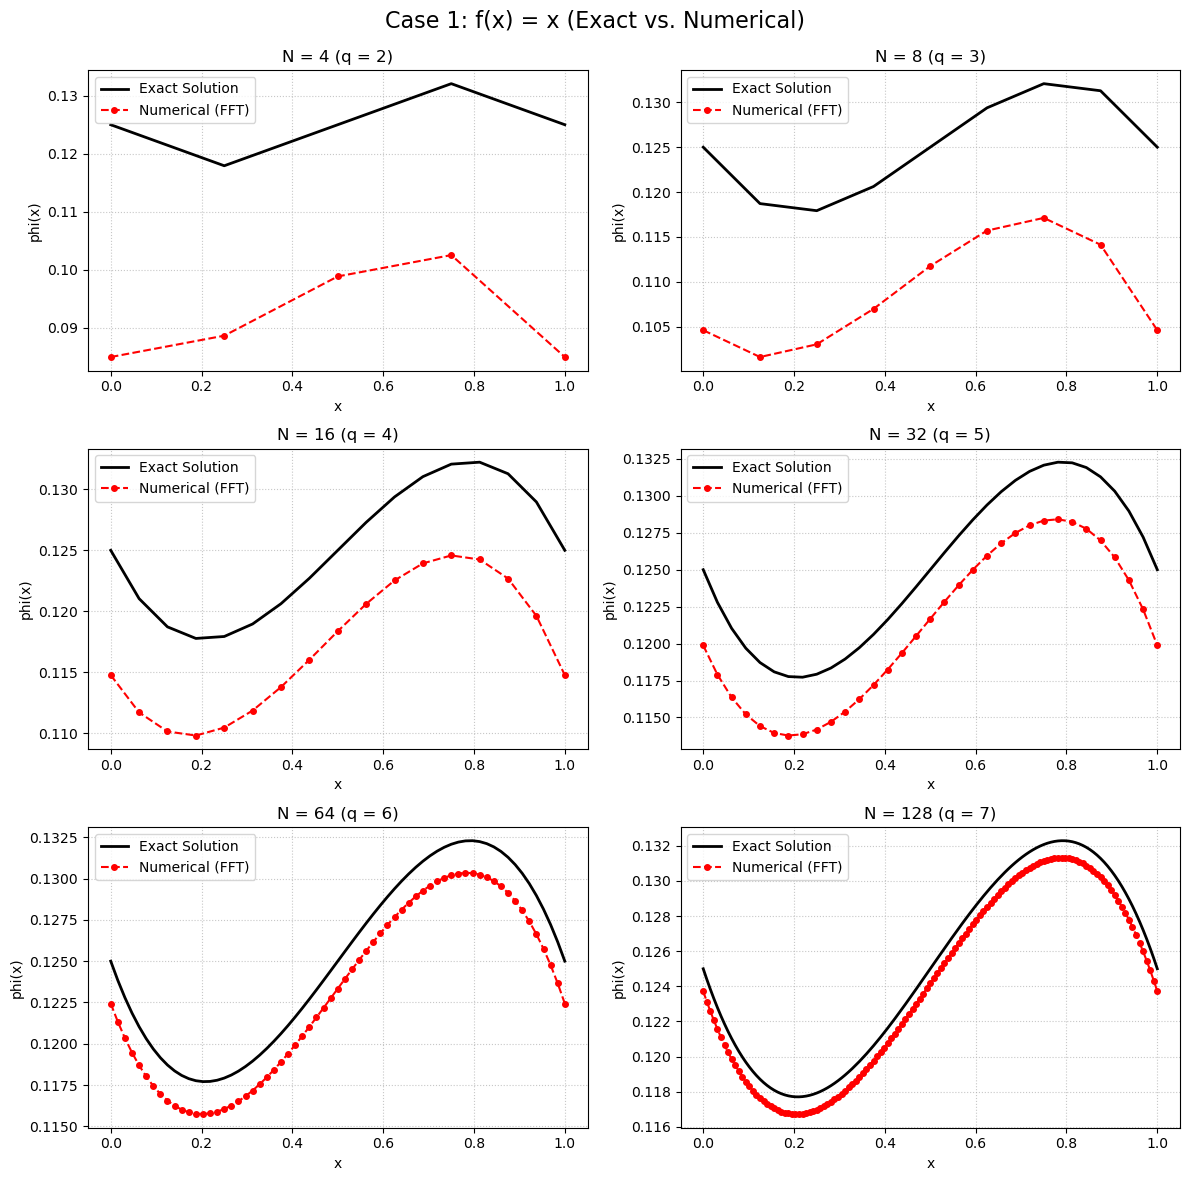

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.040033,0.160131,0.640523
1,0.125000,0.020387,0.163095,1.304760
2,0.062500,0.010242,0.163869,2.621897
3,0.031250,0.005127,0.164064,5.250050
4,0.015625,0.002564,0.164113,10.503236
5,0.007812,0.001282,0.164125,21.008041


In [3]:
# Executing/Plotting Case 1
results_case1 = []

def rhs_func_1(x):
    return x

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Case 1: f(x) = x (Exact vs. Numerical)", fontsize = 16)



for i, q in enumerate(range(2, 8)):
    N = 2 ** q

    # Run FFT solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_fft(N, exact_phi_1, rhs_func_1)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + numerical solutions
    ax.plot(x_plot, exact_plot, 'k-', label = "Exact Solution", linewidth = 2)
    ax.plot(x_plot, u_plot, 'r--', label = "Numerical (FFT)", marker = 'o', markersize = 4)
    
    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle = ':', alpha = 0.7)
    ax.legend()


    # Get the metrics for data table
    results_case1.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h ** 2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()


#Create, display the error table using Pandas
df_case1 = pd.DataFrame(results_case1)
df_case1

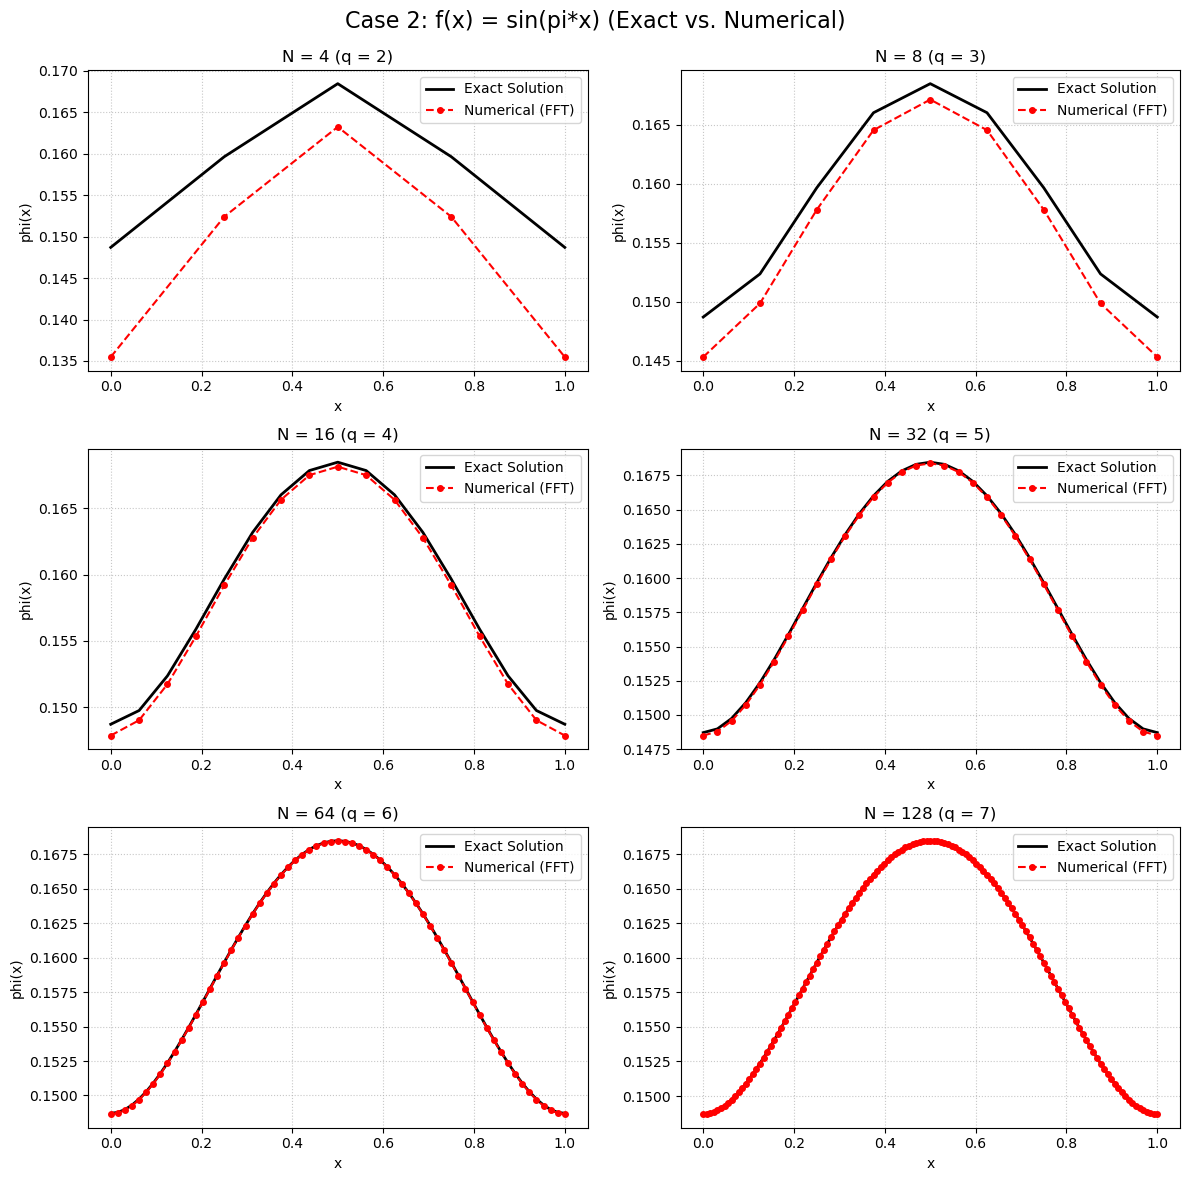

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.013231,0.052923,0.211690
1,0.125000,0.003384,0.027071,0.216568
2,0.062500,0.000851,0.013615,0.217838
3,0.031250,0.000213,0.006817,0.218159
4,0.015625,0.000053,0.003410,0.218240
5,0.007812,0.000013,0.001705,0.218260


In [4]:
#Execute/Plotting Case 2
def rhs_func_2(x):
    return np.sin(np.pi * x)

results_case2 = []

fig, axs = plt.subplots(3, 2, figsize = (12, 12))
fig.suptitle("Case 2: f(x) = sin(pi*x) (Exact vs. Numerical)", fontsize= 16)

for i, q in enumerate(range(2, 8)):
    N = 2**q

    # Run FFT solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_fft(N, exact_phi_2, rhs_func_2)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + numerical solutions
    ax.plot(x_plot, exact_plot, 'k-', label = "Exact Solution", linewidth = 2)
    ax.plot(x_plot, u_plot, 'r--', label = "Numerical (FFT)", marker = 'o', markersize = 4)

    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle = ':', alpha = 0.7)
    ax.legend()

    # Get the metrics for data table
    results_case2.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h**2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top = 0.93)
plt.show()

# Create, display the error table using Pandas
df_case2 = pd.DataFrame(results_case2)
df_case2


The central finite difference method is in theory O(h^2), so dividing the error by h^2 shpuld result in a constant number as h goes to 0. However, for f_1(x) = x the error doesn't perfectly converge at O(h^2), and the 1/h^2 colun blows up. 

In case two, the error demonstrates exactly what we expect